# `SchrodingerSolver` — Solveur de l’équation de Schrödinger dépendante du temps

**Fichier source :** `src/quantum_sim/waves/schrodinger_solver.py`

---

## 1. Contexte physique

La classe `SchrodingerSolver` résout numériquement l’équation de Schrödinger 1D dépendante du temps :

$$
i\hbar \frac{\partial \psi}{\partial t} = \left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x)\right]\psi
$$

sur une grille spatiale finie. Pour limiter les réflexions artificielles aux bords, on peut activer une **zone absorbante** (CAP: Complex Absorbing Potential).

## 2. Formulation utilisée dans le code

Le membre de droite implémenté est :

$$
\frac{d\psi}{dt} = -\frac{i}{\hbar}(T + V)\psi - \Gamma(x)\psi
$$

avec :
- $T = -\frac{\hbar^2}{2m}\nabla^2$ (énergie cinétique discrétisée),
- $V(x)$ potentiel réel utilisateur,
- $\Gamma(x)$ terme absorbant positif proche des frontières.

La discrétisation spatiale du Laplacien est faite par différences finies d’ordre 2 via une matrice tridiagonale.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sim.utils.constants import ELECTRON_MASS
from quantum_sim.waves.gaussian_wave_packet import GaussianWavePacket
from quantum_sim.waves.schrodinger_solver import SchrodingerSolver

np.set_printoptions(precision=3, suppress=True)

## 3. Code source annoté

Ci-dessous, une version annotée des méthodes principales de la classe.

In [23]:
import numpy as np
from scipy import sparse
from scipy.integrate import solve_ivp

from quantum_sim.utils.constants import REDUCED_PLANCK_CONSTANT, ELECTRON_MASS
from quantum_sim.waves.wave_packet import WavePacket


class SchrodingerSolver:
    """
    Solveur TDSE 1D basé sur :
    - discrétisation en x par différences finies
    - intégration en temps via scipy.integrate.solve_ivp
    - option CAP (absorbing boundaries)
    """

    def __init__(
        self,
        x_min: float,
        x_max: float,
        n_points: int = 801,
        mass: float = ELECTRON_MASS,
        absorbing_boundaries: bool = True,
        absorb_width: float = 5.0,
        gamma_cap: float = 5e-4,
    ) -> None:
        # Validation des paramètres du domaine
        if x_min >= x_max:
            raise ValueError("x_min must be strictly less than x_max")
        if n_points < 3:
            raise ValueError("n_points must be >= 3")
        if mass <= 0:
            raise ValueError("mass must be positive")

        self.x_min = x_min
        self.x_max = x_max
        self.n_points = n_points
        self.mass = mass
        self.absorbing_boundaries = absorbing_boundaries
        self.absorb_width = absorb_width
        self.gamma_cap = gamma_cap

        # Grille spatiale uniforme
        self.x_grid = np.linspace(x_min, x_max, n_points)
        self.dx = float(self.x_grid[1] - self.x_grid[0])

        # Potentiel réel initial (libre)
        self._V = np.zeros(n_points, dtype=float)
        self._psi_0 = None

        # Opérateurs numériques
        self._laplacian = self._build_laplacian()
        self._cap = self._build_cap() if absorbing_boundaries else np.zeros(n_points)

    def _build_laplacian(self):
        # Matrice tridiagonale: [1, -2, 1] / dx²
        return sparse.diags([1.0, -2.0, 1.0], [-1, 0, 1],
                           shape=(self.n_points, self.n_points),
                           format="csr") / self.dx**2

    def _build_cap(self):
        # CAP quadratique près des bords
        V_cap = np.zeros(self.n_points, dtype=float)
        for i, xi in enumerate(self.x_grid):
            if xi < self.x_min + self.absorb_width:
                V_cap[i] = self.gamma_cap * (((self.x_min + self.absorb_width - xi) / self.absorb_width) ** 2)
            elif xi > self.x_max - self.absorb_width:
                V_cap[i] = self.gamma_cap * (((xi - (self.x_max - self.absorb_width)) / self.absorb_width) ** 2)
        return V_cap

    def set_potential(self, V: np.ndarray):
        V = np.asarray(V, dtype=float)
        if V.shape != (self.n_points,):
            raise ValueError(f"V must have shape ({self.n_points},), got {V.shape}")
        self._V = V

    def init_from_packet(self, packet: WavePacket):
        # Échantillonne ψ0 sur la grille puis normalise
        psi_raw = packet.evaluate(self.x_grid).astype(complex)
        self.init_from_array(psi_raw, normalize=True)

    def init_from_array(self, psi_0: np.ndarray, normalize: bool = True):
        # Initialise ψ0 directement depuis un tableau complexe
        psi_0 = np.asarray(psi_0, dtype=complex)
        if psi_0.shape != (self.n_points,):
            raise ValueError(f"psi_0 must have shape ({self.n_points},), got {psi_0.shape}")

        if normalize:
            norm = np.sqrt(np.trapezoid(np.abs(psi_0) ** 2) * self.dx)
            if norm <= 0 or not np.isfinite(norm):
                raise ValueError(f"Cannot normalise psi_0: norm = {norm}")
            psi_0 = psi_0 / norm

        self._psi_0 = psi_0

    def _rhs(self, t: float, psi: np.ndarray) -> np.ndarray:
        # dψ/dt = (-i/ħ)(T+V)ψ - Γψ
        hbar = REDUCED_PLANCK_CONSTANT
        kinetic = -(hbar**2 / (2.0 * self.mass)) * self._laplacian.dot(psi)
        potential_term = self._V * psi
        hamiltonian_psi = kinetic + potential_term
        absorption = self._cap * psi
        return (-1j / hbar) * hamiltonian_psi - absorption

    def solve(self, t_final: float, dt: float, method: str = "RK45") -> dict:
        if self._psi_0 is None:
            raise RuntimeError("Initial state not set")

        n_steps = max(1, int(np.ceil(t_final / dt)))
        t_eval = np.linspace(0.0, t_final, n_steps + 1)
        solution = solve_ivp(self._rhs, (0.0, t_final), self._psi_0.copy(),
                             t_eval=t_eval, method=method)
        if not solution.success:
            raise RuntimeError(f"Solver failed: {solution.message}")

        psi = solution.y
        return {
            "x": self.x_grid,
            "t": solution.t,
            "psi": psi,
            "prob": np.abs(psi)**2,
        }

## 4. Cas d’étude : propagation libre d’un paquet gaussien

On initialise un `GaussianWavePacket`, puis on le propage avec potentiel nul $V(x)=0$.

In [24]:
# Domaine spatial
x_min, x_max = -40e-9, 40e-9
n_points = 1201

# Paquet initial (décalé vers la gauche, impulsion vers +x)
packet = GaussianWavePacket(
    k_center=8e9,
    sigma_k=8e8,
    n_waves=121,
    position_center=-20e-9,
    time=0.0,
    mass=ELECTRON_MASS,
)

solver = SchrodingerSolver(
    x_min=x_min,
    x_max=x_max,
    n_points=n_points,
    mass=ELECTRON_MASS,
    absorbing_boundaries=True,
    absorb_width=8e-9,
    gamma_cap=8e13,
)

# Potentiel libre
solver.set_potential(np.zeros(n_points))

# Initialisation depuis le paquet
solver.init_from_packet(packet)

# Intégration temporelle
result = solver.solve(t_final=6e-15, dt=2e-17, method="RK45")

x = result["x"]
t = result["t"]
psi = result["psi"]
prob = result["prob"]

print("=== Résultat solveur ===")
print(f"Grille spatiale   : {x.shape}")
print(f"Grille temporelle : {t.shape}")
print(f"ψ shape           : {psi.shape}")
print(f"ρ shape           : {prob.shape}")

=== Résultat solveur ===
Grille spatiale   : (1201,)
Grille temporelle : (301,)
ψ shape           : (1201, 301)
ρ shape           : (1201, 301)


## 5. Visualisation de la densité de probabilité

On compare quelques instants clés de $|\psi(x,t)|^2$.

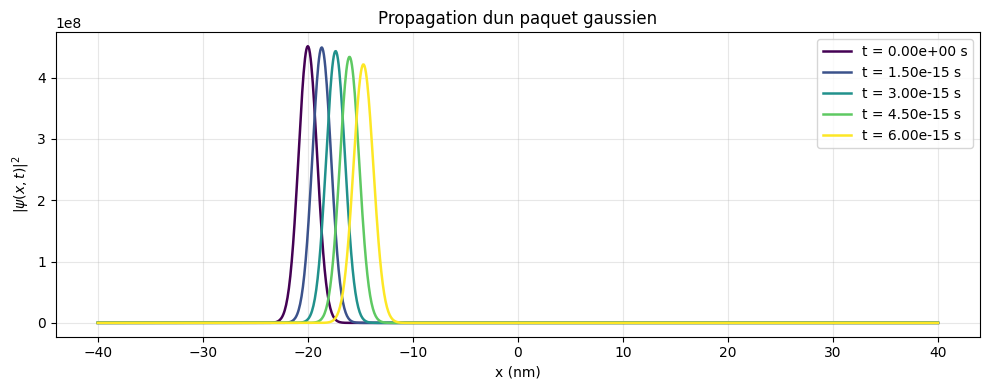

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))

indices = np.linspace(0, len(t) - 1, 5, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, len(indices)))

for idx, c in zip(indices, colors):
    ax.plot(x * 1e9, prob[:, idx], color=c, lw=1.8, label=f't = {t[idx]:.2e} s')

ax.set_xlabel('x (nm)')
ax.set_ylabel(r'$|\psi(x,t)|^2$')
ax.set_title('Propagation dun paquet gaussien')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Suivi de la norme

Sans absorption, la norme doit rester proche de 1. Avec CAP, elle peut décroître quand l’onde atteint les bords absorbants.

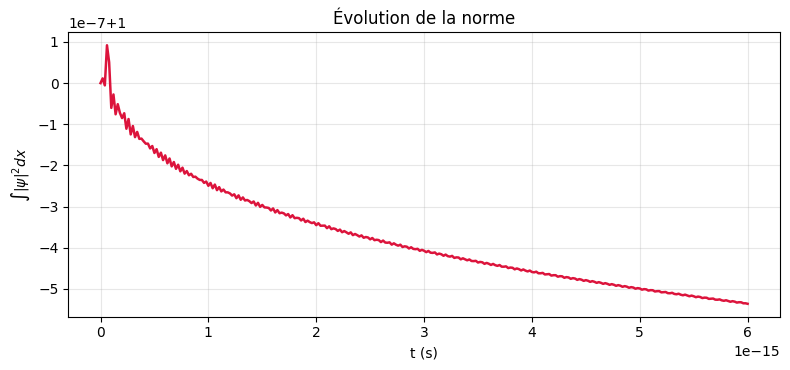

Norme min : 0.999999
Norme max : 1.000000


In [26]:
norm_t = np.trapezoid(prob, x=x, axis=0)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(t, norm_t, color='crimson', lw=1.8)
ax.set_xlabel('t (s)')
ax.set_ylabel(r'$\int |\psi|^2 dx$')
ax.set_title('Évolution de la norme')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Norme min : {norm_t.min():.6f}")
print(f"Norme max : {norm_t.max():.6f}")

## 7. Résumé du code

| Méthode / attribut | Rôle |
|---|---|
| `SchrodingerSolver(x_min, x_max, n_points, ...)` | Crée le domaine, le Laplacien et la CAP |
| `set_potential(V)` | Injecte un potentiel discret $V(x)$ |
| `init_from_packet(packet)` | Construit $\psi_0$ depuis un `WavePacket` |
| `init_from_array(psi_0)` | Initialise directement l’état initial |
| `solve(t_final, dt, method)` | Intègre la TDSE et retourne `x`, `t`, `psi`, `prob` |

---